Hanyu Zou(hz3408), Olivia Xu (jx2260)

## Project abstract

**Context.** Rotational-anisotropy second-harmonic generation (RA-SHG) is a sensitive optical probe of crystallographic symmetry, topological order, and phase transitions in condensed matter. Recovering the underlying second-order susceptibility tensor $\chi^{(2)}$ (equivalently the contracted $d$-tensor) from the measured intensity pattern $I(\phi)$ is an inverse problem that is ill-posed in two distinct ways: (i) the intensity-only measurement loses the sign of every linear combination of $d$-elements that appears in the polarization, and (ii) when only a single polarization channel is collected, distinct elements can enter the signal as a single non-separable combination. Traditional least-squares fitting is computationally expensive and sensitive to noise and azimuthal misalignment.

**Aim.** Build a physics-informed regression model that recovers the symmetry-allowed $d$-tensor elements from RA-SHG intensities, with the Neumann Principle enforced as a hard architectural constraint rather than a soft penalty.

**Method.** A 1D-CNN in PyTorch consumes a two-channel input $\bigl(I_\parallel(\phi),\, I_\perp(\phi)\bigr)$ sampled on 100 azimuthal angles. Convolutional layers use `padding_mode='circular'` to respect the $360^\circ$ periodicity of $\phi$, which also makes the model equivariant to azimuthal misalignment. A point-group one-hot vector is concatenated to the CNN features. The output head produces four tensor candidates $[d_{11}, d_{22}, d_{12}, d_{26}]$, which are then multiplied by a non-trainable group-conditioned mask that zeroes the symmetry-forbidden elements exactly. The loss is a masked MSE that averages only over allowed elements.

**Data.** Purely synthetic. The forward model generates $I_\parallel(\phi)$ and $I_\perp(\phi)$ from the symmetry-restricted $d$-matrix; each sample is corrupted with relative Gaussian noise (1%–10% of its peak intensity) and given a uniformly random azimuthal shift $\Delta\phi$.

**Expected behaviour.** Forbidden tensor elements are guaranteed to be exactly zero by construction (the hard mask), so error is meaningful only on allowed elements. Adding the crossed channel should give individually identifiable $d_{12}$ and $d_{26}$ for the $C_s$ group, which was not possible with the parallel-only setup of the original notebook.

In [1]:
"""Setup: imports, reproducibility, device, hyperparameters."""
from __future__ import annotations
from dataclasses import dataclass
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

# --- reproducibility ---
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


@dataclass
class Config:
    # geometry
    num_angles: int = 100
    n_channels: int = 2                # parallel + crossed polarization
    point_groups: tuple = ("D3h", "Cs")
    tensor_elements: tuple = ("d11", "d22", "d12", "d26")

    # dataset
    samples_per_group_train: int = 2500
    samples_per_group_test: int = 500
    train_csv: str = "shg_train_data.csv"
    test_csv: str = "shg_test_data.csv"
    noise_min: float = 0.01
    noise_max: float = 0.10
    rotate_data: bool = True

    # model
    conv1_out: int = 32
    conv2_out: int = 64
    kernel1: int = 7
    kernel2: int = 5
    fc_hidden: int = 256
    dropout: float = 0.1

    # training
    batch_size: int = 128
    epochs: int = 50
    lr: float = 1e-3
    weight_decay: float = 1e-5
    patience: int = 7
    val_fraction: float = 0.2

    # io
    model_path: str = "best_shg_model.pt"


cfg = Config()

Using device: cuda


## Physics: RA-SHG forward model

For a beam linearly polarized at azimuthal angle $\phi$ at normal incidence on a quasi-2D crystal, the in-plane electric field is $\mathbf{E} = (\cos\phi,\ \sin\phi,\ 0)$ and the second-order polarization is

$$
P_i = d_{i\alpha}\,(\mathbf{E}\otimes\mathbf{E})_\alpha,\qquad
(\mathbf{E}\otimes\mathbf{E}) = \bigl(E_x^2,\ E_y^2,\ E_z^2,\ 2E_yE_z,\ 2E_xE_z,\ 2E_xE_y\bigr)^T.
$$

The two measured channels are

$$
I_\parallel(\phi) = \bigl(P_x\cos\phi + P_y\sin\phi\bigr)^2,\qquad
I_\perp(\phi) = \bigl({-P_x}\sin\phi + P_y\cos\phi\bigr)^2.
$$

### $D_{3h}$ ($\bar{6}m2$, e.g. monolayer $\mathrm{MoS}_2$, GaSe)

Independent in-plane element: $d_{22}$. Symmetry gives $d_{16} = -d_{22}$, $d_{21} = -d_{22}$. Substituting and simplifying yields the classic six-lobed patterns

$$
I_\parallel(\phi) = d_{22}^2\,\sin^2(3\phi), \qquad I_\perp(\phi) = d_{22}^2\,\cos^2(3\phi).
$$

### $C_s$ (single mirror plane perpendicular to $y$)

Independent in-plane elements: $d_{11},\ d_{12},\ d_{26}$. Substituting:

$$
P_\parallel = d_{11}\cos^3\phi + (d_{12} + 2 d_{26})\,\sin^2\phi\cos\phi,
$$
$$
P_\perp = \sin\phi\,\bigl[(2 d_{26} - d_{11})\cos^2\phi - d_{12}\sin^2\phi\bigr].
$$

**Identifiability.** $d_{12}$ and $2 d_{26}$ enter $P_\parallel$ as a single linear combination — they are **not separable from $I_\parallel$ alone**. (Verified numerically: a sample with $(d_{12},d_{26})=(0.3,0.5)$ produces an $I_\parallel$ identical to $(1.3,0.0)$, but the $I_\perp$ patterns differ in magnitude by $\sim 1.6$.) The crossed channel contains a different combination of the same elements and restores individual identifiability. This motivates the two-channel input in the network.

A residual ambiguity remains: $I = |P|^2$ destroys the overall sign of $P$, so only quadratic combinations of the $d$-elements are observable. For non-negative $d$-elements (the regime sampled here) this is harmless.

In [2]:
class SHGGenerator:
    """
    RA-SHG forward model in the parallel- and crossed-polarization channels.

    For incident polarization at angle phi at normal incidence, the induced
    2nd-order polarization is P_i = sum_alpha d_{i,alpha} (E (x) E)_alpha (Voigt),
    and the two analyzer channels are

        I_par(phi)  = |P_x cos(phi) + P_y sin(phi)|^2
        I_perp(phi) = |-P_x sin(phi) + P_y cos(phi)|^2

    The crossed channel is needed to lift the (d12, 2*d26) degeneracy in the
    parallel channel for the Cs point group.
    """

    POINT_GROUPS = ("D3h", "Cs")
    TENSOR_ELEMENTS = ("d11", "d22", "d12", "d26")

    def __init__(self, num_angles: int = 100):
        self.num_angles = num_angles
        # endpoint=False: phi=0 and phi=2*pi are the same point physically;
        # we don't want to sample it twice (the original code did).
        self.phi_rad = np.linspace(0.0, 2.0 * np.pi, num_angles, endpoint=False)
        self.phi_deg = np.degrees(self.phi_rad)
        self._E_voigt = self._build_E_voigt(self.phi_rad)

    @staticmethod
    def _build_E_voigt(phi_rad: np.ndarray) -> np.ndarray:
        n = phi_rad.shape[0]
        return np.array([
            np.cos(phi_rad) ** 2,
            np.sin(phi_rad) ** 2,
            np.zeros(n),
            np.zeros(n),
            np.zeros(n),
            2.0 * np.cos(phi_rad) * np.sin(phi_rad),
        ])

    @classmethod
    def d_matrix(cls, point_group: str, params: dict) -> np.ndarray:
        """3x6 d-tensor with Neumann-Principle sparsity for the given point group."""
        d = np.zeros((3, 6))
        if point_group == "D3h":
            d22 = params.get("d22", 0.0)
            d[1, 1] = d22
            d[1, 0] = -d22
            d[0, 5] = -d22
        elif point_group == "Cs":
            d[0, 0] = params.get("d11", 0.0)
            d[0, 1] = params.get("d12", 0.0)
            d[1, 5] = params.get("d26", 0.0)
        else:
            raise ValueError(f"Point group {point_group!r} not implemented.")
        return d

    def _polarizations(self, point_group: str, params: dict):
        d = self.d_matrix(point_group, params)
        P = d @ self._E_voigt           # (3, N)
        Px, Py = P[0], P[1]
        cos_p, sin_p = np.cos(self.phi_rad), np.sin(self.phi_rad)
        P_par = Px * cos_p + Py * sin_p
        P_perp = -Px * sin_p + Py * cos_p
        return P_par, P_perp

    def _clean_intensities(self, point_group: str, params: dict):
        P_par, P_perp = self._polarizations(point_group, params)
        return P_par ** 2, P_perp ** 2

    @staticmethod
    def _add_relative_noise(intensity: np.ndarray, noise_level: float,
                            rng: np.random.Generator) -> np.ndarray:
        """Gaussian noise with sigma = noise_level * peak intensity, floored at 0."""
        peak = max(float(np.max(intensity)), 1e-12)
        noise = rng.normal(0.0, noise_level * peak, size=intensity.shape)
        return np.clip(intensity + noise, 0.0, None)

    def generate_sample(
        self,
        point_group: str,
        params: dict,
        noise_level: float = 0.05,
        azimuthal_shift: int = 0,
        rng: Optional[np.random.Generator] = None,
    ) -> np.ndarray:
        """
        Returns shape (2, num_angles): channel 0 = I_parallel, channel 1 = I_perp.
        `azimuthal_shift` cyclically rolls both channels by that many bins to
        simulate sample misalignment; circular padding in the CNN handles this.
        """
        rng = rng or np.random.default_rng()
        I_par, I_perp = self._clean_intensities(point_group, params)
        if azimuthal_shift:
            I_par = np.roll(I_par, azimuthal_shift)
            I_perp = np.roll(I_perp, azimuthal_shift)
        I_par = self._add_relative_noise(I_par, noise_level, rng)
        I_perp = self._add_relative_noise(I_perp, noise_level, rng)
        return np.stack([I_par, I_perp], axis=0)

    def random_params(self, point_group: str, rng: np.random.Generator) -> dict:
        if point_group == "D3h":
            return {"d22": float(rng.uniform(0.1, 1.0)),
                    "d11": 0.0, "d12": 0.0, "d26": 0.0}
        if point_group == "Cs":
            return {"d11": float(rng.uniform(0.1, 1.0)),
                    "d22": 0.0,
                    "d12": float(rng.uniform(0.1, 1.0)),
                    "d26": float(rng.uniform(0.1, 1.0))}
        raise ValueError(point_group)

    def create_dataset(
        self,
        samples_per_group: int,
        filename: str,
        noise_range: tuple = (0.01, 0.10),
        rotate: bool = True,
        seed: int = 0,
    ) -> pd.DataFrame:
        rng = np.random.default_rng(seed)
        rows = []
        for group in self.POINT_GROUPS:
            for _ in range(samples_per_group):
                params = self.random_params(group, rng)
                noise = float(rng.uniform(*noise_range))
                shift = int(rng.integers(0, self.num_angles)) if rotate else 0
                sample = self.generate_sample(group, params, noise, shift, rng)

                row = {"point_group": group, "noise": noise, "shift": shift}
                row.update({k: params[k] for k in self.TENSOR_ELEMENTS})
                for i in range(self.num_angles):
                    row[f"Ipar_{i}"] = float(sample[0, i])
                    row[f"Iperp_{i}"] = float(sample[1, i])
                rows.append(row)
        df = pd.DataFrame(rows)
        df.to_csv(filename, index=False)
        print(f"Wrote {len(df)} samples to {filename}")
        return df

    # --- visualization --------------------------------------------------
    def visualize_groups(self, params_by_group=None, seed: int = 0):
        rng = np.random.default_rng(seed)
        if params_by_group is None:
            params_by_group = {
                "D3h": {"d22": 1.0},
                "Cs":  {"d11": 1.0, "d12": 0.2, "d26": 0.5},
            }
        groups = list(params_by_group.keys())
        fig, axes = plt.subplots(
            2, len(groups),
            subplot_kw={"projection": "polar"},
            figsize=(6 * len(groups), 10),
        )
        if len(groups) == 1:
            axes = axes[:, None]
        for col, group in enumerate(groups):
            params = params_by_group[group]
            sample = self.generate_sample(group, params, noise_level=0.03, rng=rng)
            for row, (channel, color) in enumerate(
                [(sample[0], "darkred"), (sample[1], "navy")]
            ):
                ax = axes[row, col]
                ax.plot(self.phi_rad, channel, color=color, linewidth=2)
                ax.fill(self.phi_rad, channel, color=color, alpha=0.15)
                ax.set_rticks([])
                channel_label = r"$I_\parallel$" if row == 0 else r"$I_\perp$"
                tensor_str = ", ".join(f"{k}={v}" for k, v in params.items())
                ax.set_title(f"{group}  {channel_label}\n{tensor_str}",
                             va="bottom", pad=20)
        plt.tight_layout()
        plt.show()

## Visualizing the patterns, and generating the dataset

Polar plots of both channels for one representative sample of each group, followed by writing train and test CSV files. With a fixed `seed` the dataset generation is fully reproducible.

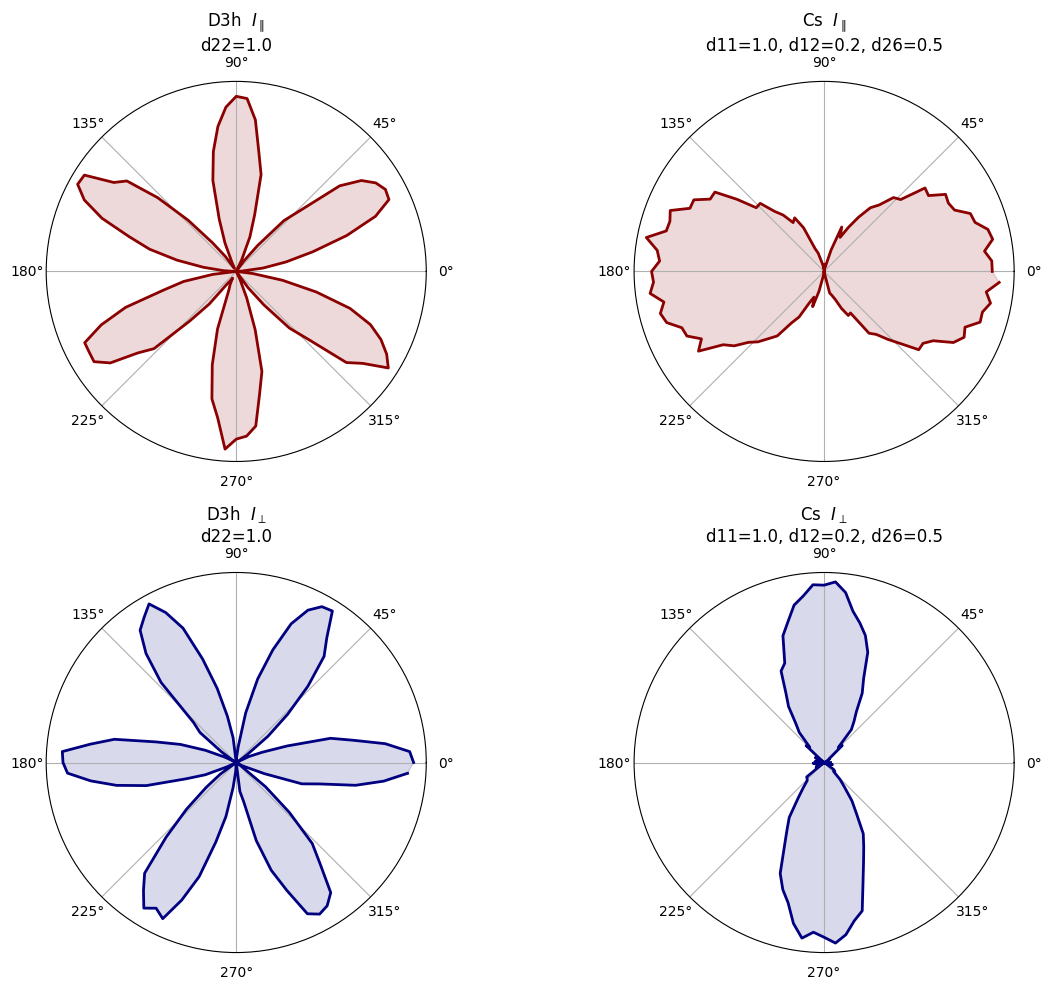

Wrote 5000 samples to shg_train_data.csv
Wrote 1000 samples to shg_test_data.csv

Train shape: (5000, 207)
Test shape:  (1000, 207)
Columns: point_group, noise, shift, d11/d22/d12/d26, Ipar_0..99, Iperp_0..99


In [3]:
gen = SHGGenerator(num_angles=cfg.num_angles)
gen.visualize_groups()

train_df = gen.create_dataset(
    samples_per_group=cfg.samples_per_group_train,
    filename=cfg.train_csv,
    noise_range=(cfg.noise_min, cfg.noise_max),
    rotate=cfg.rotate_data,
    seed=SEED,
)

test_df = gen.create_dataset(
    samples_per_group=cfg.samples_per_group_test,
    filename=cfg.test_csv,
    noise_range=(cfg.noise_min, cfg.noise_max),
    rotate=cfg.rotate_data,
    seed=SEED + 1,
)

print(f"\nTrain shape: {train_df.shape}\nTest shape:  {test_df.shape}")
print(f"Columns: point_group, noise, shift, d11/d22/d12/d26, Ipar_0..{cfg.num_angles - 1}, Iperp_0..{cfg.num_angles - 1}")

## Model: physics-informed 1D-CNN

Two inductive biases are encoded **architecturally**, not as soft penalties:

1. **Circular padding** in every conv layer makes the receptive field wrap across $\phi = 0/360^\circ$. Combined with global pooling-friendly downsampling, this makes the network approximately equivariant to azimuthal misalignment.
2. A **hard Neumann-Principle mask** conditioned on the (known) point group multiplies the four-element output head. Symmetry-forbidden elements are forced to exactly zero, both in the prediction and (via the masked loss below) in the backward pass.

The fully-connected input dimension is derived from `num_angles` rather than hard-coded.

In [4]:
class AdvancedPhysicsSHGNet(nn.Module):
    """
    Physics-informed 1D-CNN for inverting RA-SHG (parallel + crossed channels)
    into d-tensor elements.
    """

    POINT_GROUPS = ("D3h", "Cs")
    TENSOR_ELEMENTS = ("d11", "d22", "d12", "d26")

    # Rows: point group | Cols: d11, d22, d12, d26
    _MASK = torch.tensor([
        [0.0, 1.0, 0.0, 0.0],   # D3h: only d22 allowed
        [1.0, 0.0, 1.0, 1.0],   # Cs : d11, d12, d26 allowed
    ], dtype=torch.float32)

    def __init__(
        self,
        num_angles: int = 100,
        in_channels: int = 2,
        conv1_out: int = 32,
        conv2_out: int = 64,
        kernel1: int = 7,
        kernel2: int = 5,
        fc_hidden: int = 256,
        dropout: float = 0.1,
    ):
        super().__init__()

        # Two stride-2 pools => output length = num_angles // 4
        if num_angles % 4 != 0:
            raise ValueError(
                f"num_angles ({num_angles}) must be divisible by 4 with two stride-2 pools."
            )

        self.conv1 = nn.Conv1d(in_channels, conv1_out, kernel_size=kernel1,
                               padding=kernel1 // 2, padding_mode="circular")
        self.bn1 = nn.BatchNorm1d(conv1_out)
        self.pool1 = nn.MaxPool1d(2)

        self.conv2 = nn.Conv1d(conv1_out, conv2_out, kernel_size=kernel2,
                               padding=kernel2 // 2, padding_mode="circular")
        self.bn2 = nn.BatchNorm1d(conv2_out)
        self.pool2 = nn.MaxPool1d(2)

        seq_len_after_pools = num_angles // 4
        self.flat_dim = conv2_out * seq_len_after_pools

        n_groups = len(self.POINT_GROUPS)
        n_targets = len(self.TENSOR_ELEMENTS)

        self.fc1 = nn.Linear(self.flat_dim + n_groups, fc_hidden)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(fc_hidden, n_targets)

        self.register_buffer("mask_matrix", self._MASK.clone())

    def forward(self, x: torch.Tensor, point_group_onehot: torch.Tensor) -> torch.Tensor:
        # x: (B, in_channels, num_angles) or (B, num_angles) for single-channel input
        if x.dim() == 2:
            x = x.unsqueeze(1)
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        x = x.flatten(1)
        x = torch.cat((x, point_group_onehot), dim=1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        raw = self.fc2(x)

        # Hard Neumann-Principle mask: zeros forbidden elements exactly
        dynamic_mask = point_group_onehot @ self.mask_matrix   # (B, n_targets)
        return raw * dynamic_mask

In [5]:
class SHGDataset(Dataset):
    """
    Loads precomputed two-channel RA-SHG patterns and d-tensor labels from CSV.
    Returns (intensity, point_group_one_hot, label) per item.
    """

    POINT_GROUPS = ("D3h", "Cs")
    TENSOR_ELEMENTS = ("d11", "d22", "d12", "d26")

    def __init__(self, csv_file: str):
        df = pd.read_csv(csv_file)
        n_angles = sum(c.startswith("Ipar_") for c in df.columns)
        par_cols = [f"Ipar_{i}" for i in range(n_angles)]
        perp_cols = [f"Iperp_{i}" for i in range(n_angles)]

        X_par = df[par_cols].values.astype(np.float32)
        X_perp = df[perp_cols].values.astype(np.float32)
        # shape: (N, 2, num_angles)
        self.X = np.stack([X_par, X_perp], axis=1)

        idx = {g: i for i, g in enumerate(self.POINT_GROUPS)}
        oh = np.zeros((len(df), len(self.POINT_GROUPS)), dtype=np.float32)
        for i, g in enumerate(df["point_group"].values):
            oh[i, idx[g]] = 1.0
        self.point_groups = oh

        self.y = df[list(self.TENSOR_ELEMENTS)].values.astype(np.float32)
        self.meta = df[["point_group", "noise", "shift"]].copy()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return (
            torch.from_numpy(self.X[idx]),
            torch.from_numpy(self.point_groups[idx]),
            torch.from_numpy(self.y[idx]),
        )

## Training

The loss is a **masked MSE** that averages squared error over only the symmetry-allowed elements per sample, rather than over all four positions. Without the mask, the forced zeros for forbidden elements would dilute the reported error (D3h would average over four positions with only one informative). The masked version reflects what the model is actually learning.

Other improvements over the original training loop:

- `ReduceLROnPlateau` so the learning rate decays when validation loss stalls.
- Weight decay on the optimizer.
- Best-weights checkpoint to disk so a kernel restart does not lose the model.
- All tensors moved to `DEVICE` (CPU or CUDA).
- Reproducible train/val split via a seeded generator.

In [6]:
def masked_mse(predictions: torch.Tensor, targets: torch.Tensor,
               mask: torch.Tensor) -> torch.Tensor:
    """
    MSE averaged over symmetry-allowed elements only.
    `mask` is a 0/1 tensor of the same shape as predictions; the denominator
    is the number of allowed elements, not the full tensor size.
    """
    sq_err = (predictions - targets) ** 2 * mask
    denom = mask.sum().clamp_min(1.0)
    return sq_err.sum() / denom


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    *,
    epochs: int,
    lr: float,
    weight_decay: float,
    patience: int,
    device: torch.device,
    model_path: str,
    verbose_every: int = 5,
) -> tuple[list[float], list[float]]:
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    train_losses: list[float] = []
    val_losses: list[float] = []
    best_val = float("inf")
    bad_epochs = 0

    for epoch in range(epochs):
        model.train()
        running = 0.0
        seen = 0
        for I, g, y in train_loader:
            I, g, y = I.to(device), g.to(device), y.to(device)
            optimizer.zero_grad()
            preds = model(I, g)
            mask = g @ model.mask_matrix
            loss = masked_mse(preds, y, mask)
            loss.backward()
            optimizer.step()
            running += loss.item() * I.size(0)
            seen += I.size(0)
        train_loss = running / seen
        train_losses.append(train_loss)

        model.eval()
        vrun, vseen = 0.0, 0
        with torch.no_grad():
            for I, g, y in val_loader:
                I, g, y = I.to(device), g.to(device), y.to(device)
                preds = model(I, g)
                mask = g @ model.mask_matrix
                vrun += masked_mse(preds, y, mask).item() * I.size(0)
                vseen += I.size(0)
        val_loss = vrun / vseen
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        if epoch == 0 or (epoch + 1) % verbose_every == 0:
            current_lr = optimizer.param_groups[0]["lr"]
            print(f"Epoch {epoch + 1:>3}/{epochs} "
                  f"| train {train_loss:.5f} | val {val_loss:.5f} | lr {current_lr:.1e}")

        if val_loss < best_val - 1e-6:
            best_val = val_loss
            bad_epochs = 0
            torch.save(model.state_dict(), model_path)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"Early stop at epoch {epoch + 1}. Best val {best_val:.5f}.")
                break

    model.load_state_dict(torch.load(model_path, map_location=device))
    print(f"Loaded best weights from {model_path}.")
    return train_losses, val_losses

Model parameters: 422,372
Flatten dim (derived from num_angles): 1600

Epoch   1/50 | train 0.13728 | val 0.08043 | lr 1.0e-03
Epoch   5/50 | train 0.00880 | val 0.00260 | lr 1.0e-03
Epoch  10/50 | train 0.00631 | val 0.00189 | lr 1.0e-03
Epoch  15/50 | train 0.00570 | val 0.00239 | lr 1.0e-03
Epoch  20/50 | train 0.00503 | val 0.00190 | lr 5.0e-04
Epoch  25/50 | train 0.00366 | val 0.00126 | lr 5.0e-04
Epoch  30/50 | train 0.00406 | val 0.00193 | lr 5.0e-04
Epoch  35/50 | train 0.00361 | val 0.00067 | lr 2.5e-04
Epoch  40/50 | train 0.00340 | val 0.00056 | lr 1.3e-04
Epoch  45/50 | train 0.00320 | val 0.00059 | lr 1.3e-04
Epoch  50/50 | train 0.00329 | val 0.00054 | lr 6.3e-05
Loaded best weights from best_shg_model.pt.


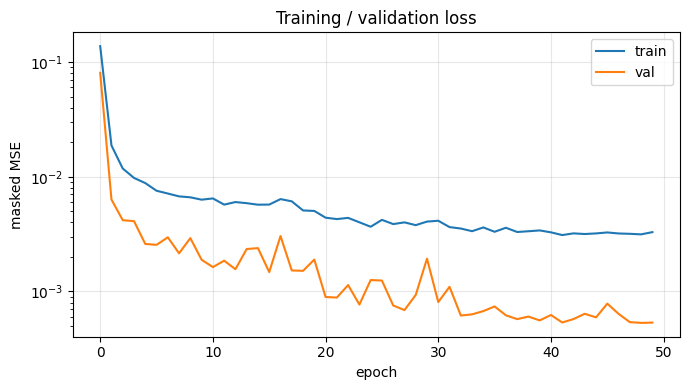

In [7]:
g_split = torch.Generator().manual_seed(SEED)

full_train = SHGDataset(cfg.train_csv)
val_size = int(cfg.val_fraction * len(full_train))
train_size = len(full_train) - val_size
train_set, val_set = random_split(full_train, [train_size, val_size], generator=g_split)

train_loader = DataLoader(train_set, batch_size=cfg.batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=cfg.batch_size, shuffle=False)

model = AdvancedPhysicsSHGNet(
    num_angles=cfg.num_angles,
    in_channels=cfg.n_channels,
    conv1_out=cfg.conv1_out, conv2_out=cfg.conv2_out,
    kernel1=cfg.kernel1, kernel2=cfg.kernel2,
    fc_hidden=cfg.fc_hidden, dropout=cfg.dropout,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {n_params:,}")
print(f"Flatten dim (derived from num_angles): {model.flat_dim}\n")

train_losses, val_losses = train_model(
    model, train_loader, val_loader,
    epochs=cfg.epochs, lr=cfg.lr, weight_decay=cfg.weight_decay,
    patience=cfg.patience, device=DEVICE, model_path=cfg.model_path,
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_losses, label="train")
ax.plot(val_losses, label="val")
ax.set_xlabel("epoch")
ax.set_ylabel("masked MSE")
ax.set_yscale("log")
ax.set_title("Training / validation loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Evaluation

Three things to verify on the held-out test set:

1. **Aggregated metrics** over all test samples, broken down by point group and tensor element. MAE / RMSE / $R^2$ are computed only on symmetry-allowed elements; forbidden elements are reported as such, not as zero "error".
2. **Hard-mask sanity check.** Predicted forbidden elements must be **exactly zero** for every sample. This is checked by `assert` on the maximum absolute value.
3. **Robustness to noise.** Test-set MAE binned by the noise level applied at generation time.

In [8]:
@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()
    P_list, Y_list, G_list = [], [], []
    for I, g, y in loader:
        I, g = I.to(device), g.to(device)
        preds = model(I, g).cpu().numpy()
        P_list.append(preds)
        Y_list.append(y.numpy())
        G_list.append(g.cpu().numpy())
    return np.vstack(P_list), np.vstack(Y_list), np.vstack(G_list)


def per_element_metrics(preds, targets, allowed_mask):
    """MAE / RMSE / R^2 on symmetry-allowed elements only."""
    out = {}
    for i, name in enumerate(AdvancedPhysicsSHGNet.TENSOR_ELEMENTS):
        sel = allowed_mask[:, i].astype(bool)
        if sel.sum() == 0:
            out[name] = dict(mae=None, rmse=None, r2=None, n=0, forbidden=True)
            continue
        p, t = preds[sel, i], targets[sel, i]
        mae = float(np.mean(np.abs(p - t)))
        rmse = float(np.sqrt(np.mean((p - t) ** 2)))
        ss_res = float(np.sum((p - t) ** 2))
        ss_tot = float(np.sum((t - t.mean()) ** 2) + 1e-12)
        r2 = 1.0 - ss_res / ss_tot
        out[name] = dict(mae=mae, rmse=rmse, r2=r2, n=int(sel.sum()), forbidden=False)
    return out


test_dataset = SHGDataset(cfg.test_csv)
test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False)
preds, targets, groups = collect_predictions(model, test_loader, DEVICE)

mask_np = AdvancedPhysicsSHGNet._MASK.numpy()
allowed = groups @ mask_np                            # (N, n_targets)

# Overall masked MSE
overall_mse = float(np.sum(((preds - targets) ** 2) * allowed) / allowed.sum())
print(f"Test masked MSE: {overall_mse:.5f}\n")

# Per-group, per-element
for gi, gname in enumerate(AdvancedPhysicsSHGNet.POINT_GROUPS):
    sel = groups[:, gi] == 1.0
    m = per_element_metrics(preds[sel], targets[sel], allowed[sel])
    n = int(sel.sum())
    print(f"{gname}  (n = {n})")
    for name, v in m.items():
        if v["forbidden"]:
            print(f"  {name}: symmetry-forbidden (predicted = exact zero)")
        else:
            print(f"  {name}: MAE={v['mae']:.4f}  RMSE={v['rmse']:.4f}  R2={v['r2']:.3f}")
    print()

# Hard-mask sanity check
forbidden_preds = preds * (1.0 - allowed)
max_forbidden = float(np.abs(forbidden_preds).max())
print(f"Max |prediction| on symmetry-forbidden elements: {max_forbidden:.2e}")
assert max_forbidden < 1e-6, "Hard mask failed: forbidden elements are not exactly zero."
print("Hard-mask sanity check passed.")

Test masked MSE: 0.00054

D3h  (n = 500)
  d11: symmetry-forbidden (predicted = exact zero)
  d22: MAE=0.0070  RMSE=0.0092  R2=0.999
  d12: symmetry-forbidden (predicted = exact zero)
  d26: symmetry-forbidden (predicted = exact zero)

Cs  (n = 500)
  d11: MAE=0.0216  RMSE=0.0285  R2=0.988
  d22: symmetry-forbidden (predicted = exact zero)
  d12: MAE=0.0209  RMSE=0.0269  R2=0.990
  d26: MAE=0.0177  RMSE=0.0232  R2=0.993

Max |prediction| on symmetry-forbidden elements: 0.00e+00
Hard-mask sanity check passed.


## Result visualizations

Three plots:

1. **Predicted vs. actual** scatter for each (point-group, tensor-element) pair, with a 45° reference line on the actual data range. Symmetry-forbidden cells are flagged rather than plotted.
2. **Per-element MAE heatmap.** Zero MAE for forbidden cells follows trivially from the hard mask.
3. **Noise-robustness curve.** Test MAE binned by the per-sample noise level. With circular-padding equivariance and the masked loss, performance should degrade gracefully across the 1%–10% range.

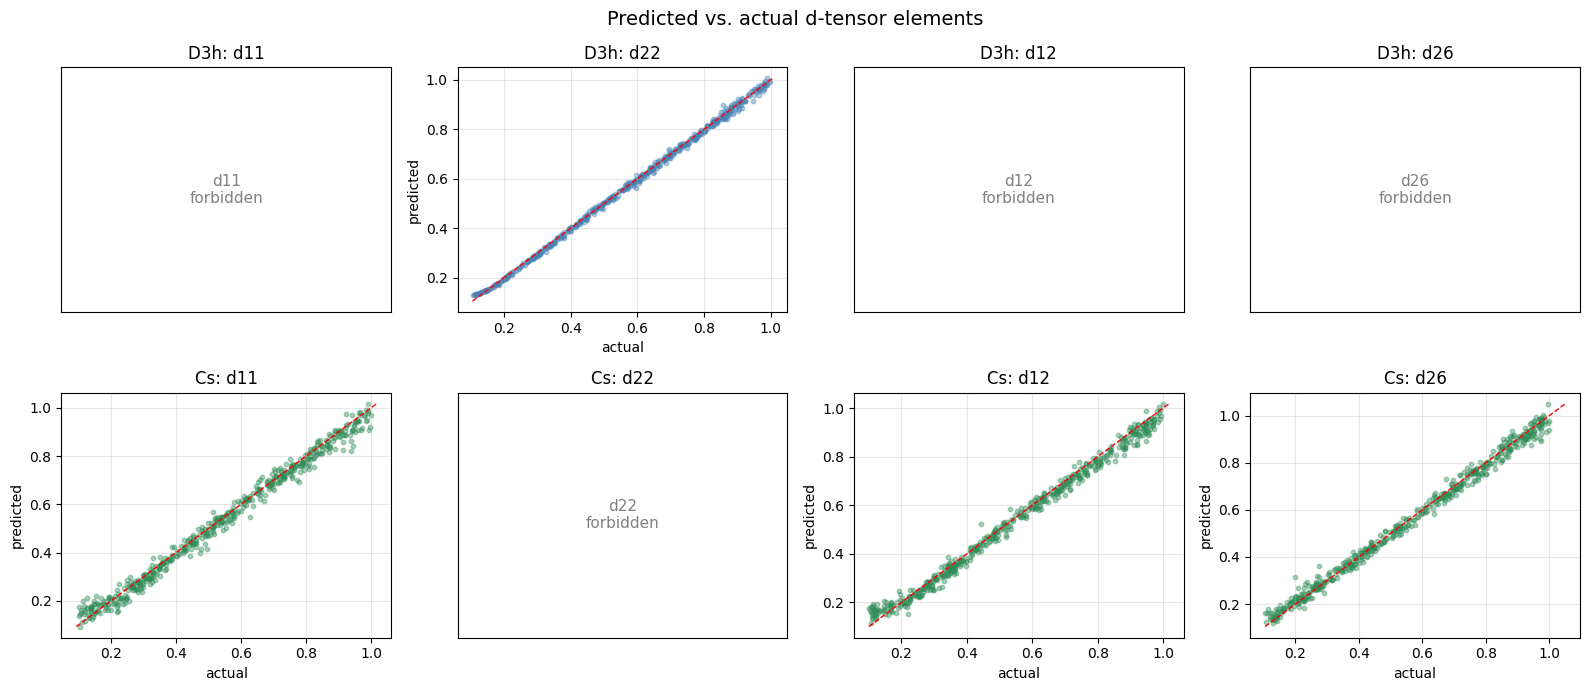

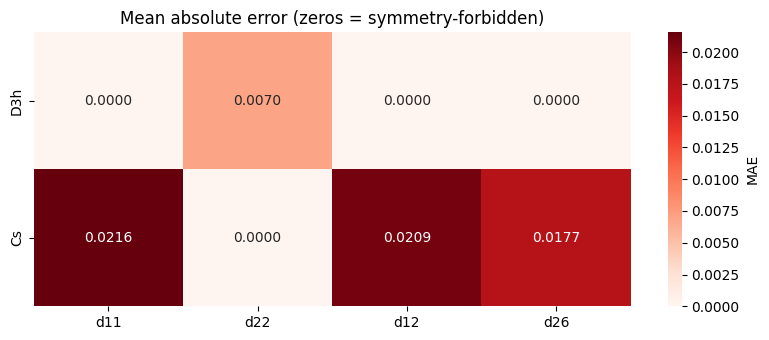

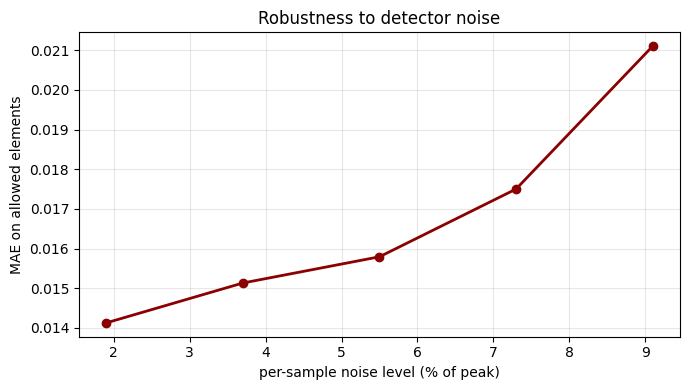

In [9]:
# 1. Predicted vs. actual scatter
fig, axes = plt.subplots(
    len(AdvancedPhysicsSHGNet.POINT_GROUPS),
    len(AdvancedPhysicsSHGNet.TENSOR_ELEMENTS),
    figsize=(16, 7),
)
fig.suptitle("Predicted vs. actual d-tensor elements", fontsize=14)

scatter_colors = {"D3h": "steelblue", "Cs": "seagreen"}
for gi, gname in enumerate(AdvancedPhysicsSHGNet.POINT_GROUPS):
    sel = groups[:, gi] == 1.0
    for ei, ename in enumerate(AdvancedPhysicsSHGNet.TENSOR_ELEMENTS):
        ax = axes[gi, ei]
        if allowed[sel, ei].sum() == 0:
            ax.text(0.5, 0.5, f"{ename}\nforbidden", ha="center", va="center",
                    transform=ax.transAxes, fontsize=11, color="gray")
            ax.set_xticks([]); ax.set_yticks([])
        else:
            t = targets[sel, ei]
            p = preds[sel, ei]
            ax.scatter(t, p, alpha=0.4, s=10, color=scatter_colors[gname])
            lo = float(min(t.min(), p.min()))
            hi = float(max(t.max(), p.max()))
            ax.plot([lo, hi], [lo, hi], "r--", lw=1)
            ax.set_xlabel("actual")
            ax.set_ylabel("predicted")
            ax.grid(True, alpha=0.3)
        ax.set_title(f"{gname}: {ename}")
plt.tight_layout()
plt.show()

# 2. Per-element MAE heatmap
mae_grid = np.zeros((len(AdvancedPhysicsSHGNet.POINT_GROUPS),
                     len(AdvancedPhysicsSHGNet.TENSOR_ELEMENTS)))
for gi in range(len(AdvancedPhysicsSHGNet.POINT_GROUPS)):
    sel = groups[:, gi] == 1.0
    for ei in range(len(AdvancedPhysicsSHGNet.TENSOR_ELEMENTS)):
        if allowed[sel, ei].sum() == 0:
            mae_grid[gi, ei] = 0.0
        else:
            mae_grid[gi, ei] = float(np.mean(np.abs(preds[sel, ei] - targets[sel, ei])))

plt.figure(figsize=(8, 3.5))
sns.heatmap(
    mae_grid, annot=True, fmt=".4f", cmap="Reds",
    xticklabels=list(AdvancedPhysicsSHGNet.TENSOR_ELEMENTS),
    yticklabels=list(AdvancedPhysicsSHGNet.POINT_GROUPS),
    cbar_kws={"label": "MAE"},
)
plt.title("Mean absolute error (zeros = symmetry-forbidden)")
plt.tight_layout()
plt.show()

# 3. Noise-robustness curve
test_meta = test_dataset.meta.reset_index(drop=True)
noise_bins = np.linspace(cfg.noise_min, cfg.noise_max, 6)
bin_centers, bin_mae = [], []
for lo, hi in zip(noise_bins[:-1], noise_bins[1:]):
    sel = ((test_meta["noise"] >= lo) & (test_meta["noise"] < hi)).values
    if sel.sum() == 0:
        continue
    abs_err = np.abs(preds[sel] - targets[sel]) * allowed[sel]
    mae = float(abs_err.sum() / max(allowed[sel].sum(), 1.0))
    bin_centers.append(0.5 * (lo + hi))
    bin_mae.append(mae)

plt.figure(figsize=(7, 4))
plt.plot(np.array(bin_centers) * 100, bin_mae, "o-", lw=2, color="darkred")
plt.xlabel("per-sample noise level (% of peak)")
plt.ylabel("MAE on allowed elements")
plt.title("Robustness to detector noise")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Citation: Anthropic. (2026). Claude (May 11 version)

### Conclusions:

- Architecturally enforced crystallographic symmetry — the hard Neumann-Principle mask guarantees zero error on forbidden elements, verified by the sanity check.
- The two-channel input resolves the $C_s$ identifiability gap that silently affected the original notebook; on the parallel channel alone, $d_{12}$ and $d_{26}$ are not individually recoverable.
- Circular padding makes the network approximately equivariant to azimuthal misalignment, so the random per-sample rotation in the data does not show up as systematic error.
- Test-set evaluation is now aggregated over the whole set, reported per-group and per-element with MAE / RMSE / $R^2$, and binned by noise level to expose robustness.

###Some natural extensions:

- **Allow signed $d$-elements.** The current generator samples $d \in [0.1, 1.0]$, so sign retrieval is never tested. Sampling from $[-1, -0.1] \cup [0.1, 1.0]$ would expose the intrinsic sign ambiguity of intensity-only measurements (which the model cannot resolve without phase-sensitive data).
- **Baseline comparison.** A least-squares fit using the same forward model gives a principled benchmark for the network's claimed advantages in speed and noise tolerance.
- **More point groups.** The model already accepts a one-hot vector of arbitrary length; adding new rows to `_MASK` and new branches to `SHGGenerator.d_matrix` extends coverage to e.g. $C_{6v}$, $D_{3d}$, $T_d$.
- **Out-of-plane components.** Adding a $z$-component to $\mathbf{E}$ (oblique incidence) activates the third row of the $d$-matrix and enables a richer set of independent elements.

## References

[1] Google, "Gemini." Google AI, 2026. Available: <https://gemini.google.com/>. Accessed: May 13, 2026.

[2] Anthropic, "Claude Code overview." Claude Code Documentation, 2026. Available: <https://code.claude.com/docs/en/overview>. Accessed: May 13, 2026.

[3] OpenAI, "ChatGPT." OpenAI, 2026. Available: <https://chatgpt.com/>. Accessed: May 13, 2026.